# Rabi oscillation

In [1]:
from pathlib import Path

import numpy as np

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.experiments.cal08_rabi import Rabi

## Run parameters

In [28]:
HARDWARE_CONFIG = Path(r"..\config\hw_config.json")
DEVICE_CONFIG = Path(r"..\config\dut_config.json")
FLUX_CONFIG = Path(r"..\config\flux_config.json")  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = Path("data")

QUBITS = ["q0"]

# Two arrays give a 2D Rabi sweep. Replace either one with a scalar for a 1D sweep.
# DRIVE_AMPLITUDES = np.arange(start=0.0, stop=0.2, step=0.01)    # 2D sweep
DRIVE_DURATIONS = np.arange(start=4, stop=200, step=4, dtype=float) * 1e-9    # 2D sweep
# DRIVE_DURATIONS = 100e-9  # power Rabi
DRIVE_AMPLITUDES = 0.1    # time Rabi
REPETITIONS = 10

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = Path(r"..\config\dut_config_upd.json")  # Use None to skip persistence

## Hardware and experiment

In [29]:
hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = Rabi(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

## Measurement

In [30]:
dataset = experiment.run_measurement(
    drive_amplitudes=DRIVE_AMPLITUDES,
    drive_durations=DRIVE_DURATIONS,
    repetitions=REPETITIONS,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    timeout=TIMEOUT,
)
dataset

c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 2kB
Dimensions:             (acq_index_S21_q0: 49)
Coordinates:
    drive_duration_q0   (acq_index_S21_q0) float64 392B 4e-09 8e-09 ... 1.96e-07
    drive_amplitude_q0  (acq_index_S21_q0) float64 392B 0.1 0.1 0.1 ... 0.1 0.1
  * acq_index_S21_q0    (acq_index_S21_q0) int64 392B 0 1 2 3 4 ... 45 46 47 48
Data variables:
    S21_q0              (acq_index_S21_q0) complex128 784B (-3.59687566757202...
Attributes:
    tuid:     20260812-125438-533-4399e4

## Optional: Simulated data

In [32]:
dataset = experiment.simulated_data(
    drive_amplitudes=DRIVE_AMPLITUDES,
    drive_durations=DRIVE_DURATIONS,
    repetitions=REPETITIONS,
    pi_pulse_amplitude=0.1,
    pi_pulse_duration=50e-9,
    noise=0.002,
    seed=42,
)

## Plot raw data

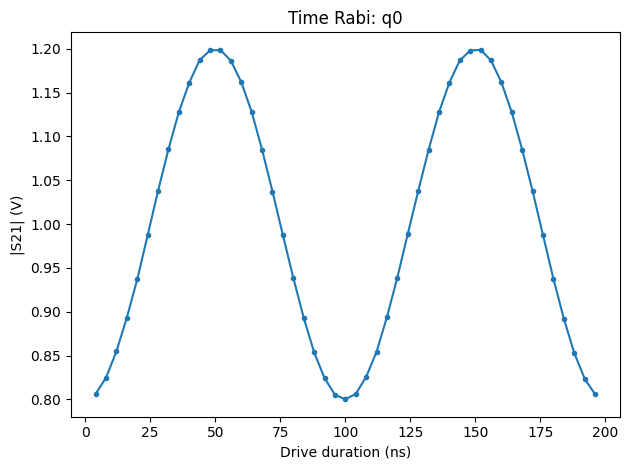

In [33]:
experiment.plot_data()

## Analysis

In [34]:
ANALYSIS_MODE = "time"  # "power" or "time"
ANALYSIS_DRIVE_DURATION = 100e-9  # Required in power mode
ANALYSIS_DRIVE_AMPLITUDE = 0.1  # Required in time mode
CALIBRATION_POINTS = True  # Rotate the complex data onto its highest-SNR axis

In [35]:
analysis_arguments = {
    "mode": ANALYSIS_MODE,
    "calibration_points": CALIBRATION_POINTS,
}
if ANALYSIS_MODE == "power":
    analysis_arguments["drive_duration"] = ANALYSIS_DRIVE_DURATION
elif ANALYSIS_MODE == "time":
    analysis_arguments["drive_amplitude"] = ANALYSIS_DRIVE_AMPLITUDE

results = experiment.analysis(**analysis_arguments)
for qubit, result in results.items():
    if not result.success:
        print(f"{qubit}: Rabi fit failed")
    elif result.mode == "power":
        print(
            f"{qubit}: pi-pulse amplitude = {result.pi_pulse_amplitude:.9g} "
            f"at {result.selected_drive_duration / 1e-9:.3f} ns"
        )
    else:
        print(
            f"{qubit}: pi-pulse duration = {result.pi_pulse_duration / 1e-9:.3f} ns "
            f"at amplitude {result.selected_drive_amplitude:.9g}"
        )

q0: pi-pulse duration = 49.990 ns at amplitude 0.1


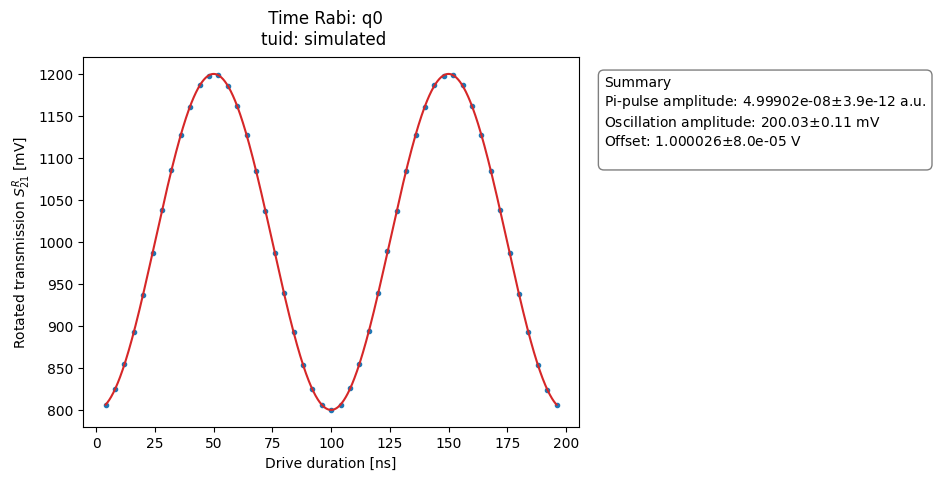

In [36]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [37]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to ..\config\dut_config_upd.json
